# Shipments

Sometimes a pickup needs to happen at one location, and be delivered to another, without any depot involvement.
Such routing problems are called VRPs with pickup and delivery, and we model it in PyVRP using *shipments*.

In [1]:
import pyvrp
import pyvrp.plotting
import pyvrp.stop

We will investigate a simple example with five shipments, inspired by the example from the [OR-Tools documentation](https://developers.google.com/optimization/routing/pickup_delivery).

In [2]:
COORDS = [
    (456, 320),
    (228, 0),
    (912, 0),
    (0, 80),
    (114, 80),
    (570, 160),
    (798, 160),
    (342, 240),
    (684, 240),
    (570, 400),
    (912, 400),
]

PICKUP_DELIVERIES = [
    (1, 6),
    (2, 10),
    (4, 3),
    (5, 9),
    (7, 8),
]

The problem has five shipments, and a maximum distance constraint of 3000 on the vehicles.
We first define all locations, and reference those when creating the depot and setting up the shipments.

In [3]:
m = pyvrp.Model()

for x, y in COORDS:
    m.add_location(x, y)

m.add_depot(location=m.locations[0])
veh_type = m.add_vehicle_type(4, max_distance=3_000)

for pickup_idx, delivery_idx in PICKUP_DELIVERIES:
    m.add_shipment(
        pickup_location=m.locations[pickup_idx],
        delivery_location=m.locations[delivery_idx],
    )

for frm in m.locations:
    for to in m.locations:
        distance = abs(frm.x - to.x) + abs(frm.y - to.y)  # Manhattan
        m.add_edge(frm, to, distance=distance)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second

PyVRP v0.14.0


Solving an instance with:


    1 depot


    0 clients


    5 shipments


...

   objective: 3652


    distance: 3652


    duration: 0


# iterations: 34606


    run-time: 1.00 seconds


The solution uses two routes because of the maximum distance constraint.

Let’s investigate the solution further.
Observe that the shipments are visited twice in each route, for example, as `L0` and `U0`.
Here, `L0` means that shipment `0` is loaded onto the vehicle (pickup), while `U0` indicates it is unloaded (delivery).
Of course, pickup of a shipment always precedes its delivery.

In [4]:
print(res.best)

Route #1: L4 L2 U2 L0 L1 U1 U0 U4
Route #2: L3 U3



Let’s have a look at the routes PyVRP determined:

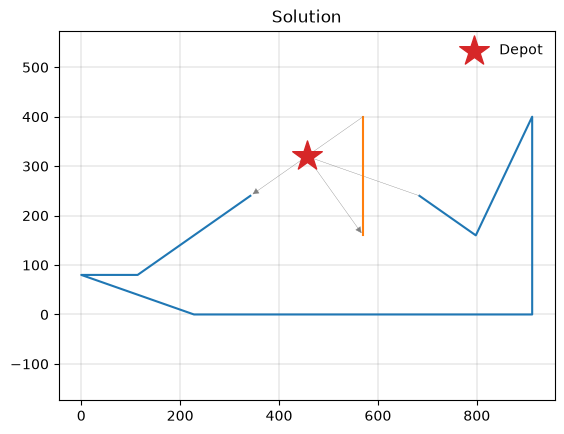

In [5]:
pyvrp.plotting.plot_solution(res.best, m.data())

## Conclusion

You now know how to use PyVRP's shipment feature.
Shipments are useful in many settings, including meal delivery, courier and taxi services, and more.
PyVRP's shipments can also be seamlessly mixed with depot-based clients.